<a href="https://colab.research.google.com/github/RCutrino/cmapss_project/blob/main/notebook/04_sensor_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMAPSS FD001 — Sensor forecasting

## Objectives

- predict future sensor values
- model engine temporal dynamics
- compare forecasting baselines
- evaluate forecasting accuracy

## Library and Environment setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from xgboost import XGBRegressor


import joblib
import sys
sys.path.append("..")
from src.RUL_forecasting import make_sequences
from src.sensor_forecasting import preprocessing, metrics, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

## Load Data

In [6]:
data_path = "../data/processed/"

In [7]:
train_df = pd.read_parquet(os.path.join(data_path, "forecast_train.parquet"))
print(train_df.shape)
print(train_df.columns)

(16145, 33)
Index(['engine_id', 'cycle', 'RUL', 'sensor_11', 'sensor_4', 'sensor_12',
       'sensor_7', 'sensor_21', 'sensor_11_rolling_mean',
       'sensor_4_rolling_mean', 'sensor_12_rolling_mean',
       'sensor_7_rolling_mean', 'sensor_21_rolling_mean',
       'sensor_11_rolling_std', 'sensor_4_rolling_std',
       'sensor_12_rolling_std', 'sensor_7_rolling_std',
       'sensor_21_rolling_std', 'sensor_11_lag_1', 'sensor_11_lag_2',
       'sensor_11_lag_3', 'sensor_4_lag_1', 'sensor_4_lag_2', 'sensor_4_lag_3',
       'sensor_12_lag_1', 'sensor_12_lag_2', 'sensor_12_lag_3',
       'sensor_7_lag_1', 'sensor_7_lag_2', 'sensor_7_lag_3', 'sensor_21_lag_1',
       'sensor_21_lag_2', 'sensor_21_lag_3'],
      dtype='object')


In [8]:
val_df = pd.read_parquet(os.path.join(data_path, "forecast_val.parquet"))
print(val_df.shape)
print(val_df.columns)

(4086, 33)
Index(['engine_id', 'cycle', 'RUL', 'sensor_11', 'sensor_4', 'sensor_12',
       'sensor_7', 'sensor_21', 'sensor_11_rolling_mean',
       'sensor_4_rolling_mean', 'sensor_12_rolling_mean',
       'sensor_7_rolling_mean', 'sensor_21_rolling_mean',
       'sensor_11_rolling_std', 'sensor_4_rolling_std',
       'sensor_12_rolling_std', 'sensor_7_rolling_std',
       'sensor_21_rolling_std', 'sensor_11_lag_1', 'sensor_11_lag_2',
       'sensor_11_lag_3', 'sensor_4_lag_1', 'sensor_4_lag_2', 'sensor_4_lag_3',
       'sensor_12_lag_1', 'sensor_12_lag_2', 'sensor_12_lag_3',
       'sensor_7_lag_1', 'sensor_7_lag_2', 'sensor_7_lag_3', 'sensor_21_lag_1',
       'sensor_21_lag_2', 'sensor_21_lag_3'],
      dtype='object')


## Forecast target creation

For single-step forecasting the target is the value of each sensor
at the next cycle (t+1).  
This is created with a **per-engine shift** to avoid leaking values
across different engines — the last cycle of each engine is dropped
since it has no next value to predict.

In [9]:
SENSORS = [col for col in train_df.columns
           if col.startswith('sensor')
           and '_rolling' not in col
           and '_lag' not in col]

In [10]:
train_df = preprocessing.add_forecast_targets(train_df, SENSORS)
val_df = preprocessing.add_forecast_targets(val_df, SENSORS)

In [11]:
TARGETS  = [f'{s}_target' for s in SENSORS]

In [12]:
print(f"Train : {train_df.shape}")
print(f"Val : {val_df.shape}")
print(f"Targets: {TARGETS}")

Train : (16045, 38)
Val : (3986, 38)
Targets: ['sensor_11_target', 'sensor_4_target', 'sensor_12_target', 'sensor_7_target', 'sensor_21_target']


## Baseline model

Two simple baselines establish the minimum performance bar:
- **Persistence model** — predicts that the next value equals the current value.  
Strong baseline for smooth sensor signals.
- **Mean predictor** — always predicts the training mean for each sensor.

In [15]:
results = {s: {} for s in SENSORS}

In [16]:
for s in SENSORS:
    # Persistence
    metrics.evaluate_forecast('Persistence',
                              val_df[s],
                              val_df[f'{s}_target'],
                              s,
                              results)

    # Mean predictor
    mean_pred = np.full(len(val_df), train_df[f'{s}_target'].mean())
    metrics.evaluate_forecast('Mean Predictor',
                              val_df[f'{s}_target'],
                              mean_pred,
                              s,
                              results)
    print()

sensor_11    Persistence          RMSE=0.5460  MAE=0.4360  R²=0.342
sensor_11    Mean Predictor       RMSE=1.8760  MAE=1.7490  R²=-6.583

sensor_4     Persistence          RMSE=0.6440  MAE=0.5150  R²=0.139
sensor_4     Mean Predictor       RMSE=1.8470  MAE=1.7120  R²=-5.918

sensor_12    Persistence          RMSE=0.5820  MAE=0.4660  R²=0.340
sensor_12    Mean Predictor       RMSE=1.8340  MAE=1.6900  R²=-5.392

sensor_7     Persistence          RMSE=0.6570  MAE=0.5200  R²=0.180
sensor_7     Mean Predictor       RMSE=1.8040  MAE=1.6580  R²=-5.092

sensor_21    Persistence          RMSE=0.7720  MAE=0.6210  R²=-0.109
sensor_21    Mean Predictor       RMSE=1.7630  MAE=1.6060  R²=-4.663



## XGBoost forecasting

One XGBoost model is trained per sensor — each model predicts the next
value of its sensor using all engineered features as input.

The rolling statistics and lag features engineered in notebook 02 give
XGBoost implicit temporal context, compensating for its inability to
model sequences directly.

Hyperparameters are fixed based on the best configuration found in
notebook 03.

In [17]:
DROP = ['engine_id', 'cycle', 'RUL'] + TARGETS
FEATURES = [col for col in train_df.columns if col not in DROP]

In [18]:
X_train = train_df[FEATURES]
X_val   = val_df[FEATURES]

In [19]:
xgb_models = {}

In [20]:
for s in SENSORS:
    y_train = train_df[f'{s}_target']
    y_val   = val_df[f'{s}_target']

    model = XGBRegressor(n_estimators=200,
                         max_depth=5,
                         learning_rate=0.05,
                         subsample=0.8,
                         random_state=42,
                         verbosity=0)
    model.fit(X_train, y_train)
    xgb_models[s] = model

    metrics.evaluate_forecast('XGBoost', y_val, model.predict(X_val), s, results);

sensor_11    XGBoost              RMSE=0.6540  MAE=0.5190  R²=0.079
sensor_4     XGBoost              RMSE=0.6540  MAE=0.5240  R²=0.134
sensor_12    XGBoost              RMSE=0.5970  MAE=0.4710  R²=0.324
sensor_7     XGBoost              RMSE=0.6590  MAE=0.5220  R²=0.186
sensor_21    XGBoost              RMSE=0.7990  MAE=0.6450  R²=-0.163


## LSTM forecasting

One LSTM model is trained per sensor using sliding window sequences
of the 5 raw sensors as input.

The sequence creation reuses `make_sequences` from `src.RUL_forecasting` with the pre-computed `_target` columns as labels — keeping the approach consistent with notebook 03.

In [21]:
SEQ_LEN = 30

In [22]:
callbacks = [EarlyStopping(monitor='val_loss',
                           patience=10,
                           restore_best_weights=True,
                           verbose=0),
             ReduceLROnPlateau(monitor='val_loss',
                               factor=0.5,
                               patience=5,
                               min_lr=1e-5,
                               verbose=0)]


In [23]:
lstm_models = {}

In [24]:
for s in SENSORS:
    print(f'Training LSTM for {s} …')

    X_train_seq, y_train_seq = make_sequences(train_df, SENSORS, f'{s}_target', SEQ_LEN)
    X_val_seq,   y_val_seq   = make_sequences(val_df,   SENSORS, f'{s}_target', SEQ_LEN)

    model = models.build_sensor_lstm(input_shape=(SEQ_LEN, len(SENSORS)))

    model.fit(X_train_seq,
              y_train_seq,
              validation_data=(X_val_seq, y_val_seq),
              epochs=100,
              batch_size=256,
              callbacks=callbacks,
              verbose=0)

    lstm_models[s] = model

    metrics.evaluate_forecast('LSTM', y_val_seq, model.predict(X_val_seq).flatten(), s, results);

Training LSTM for sensor_11 …
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
sensor_11    LSTM                 RMSE=0.5010  MAE=0.3990  R²=0.038
Training LSTM for sensor_4 …
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
sensor_4     LSTM                 RMSE=1.0000  MAE=0.8780  R²=-2.260
Training LSTM for sensor_12 …
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
sensor_12    LSTM                 RMSE=0.4510  MAE=0.3610  R²=0.396
Training LSTM for sensor_7 …
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
sensor_7     LSTM                 RMSE=0.7850  MAE=0.6530  R²=-0.753
Training LSTM for sensor_21 …
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
sensor_21    LSTM                 RMSE=0.9190  MAE=0.7700  R²=-1.213


## Model comparison

Results aggregated across all sensors.  
Lower RMSE and MAE are better; higher R² is better.

In [25]:
comparison = {}

In [26]:
for s in SENSORS:
    comparison[s] = pd.DataFrame(results[s]).T.round(3)
    print(f'── {s} ──')
    display(comparison[s])
    print()

── sensor_11 ──


,RMSE,MAE,R²
Persistence,0.546,0.436,0.342
Mean Predictor,1.876,1.749,-6.583
XGBoost,0.654,0.519,0.079
LSTM,0.501,0.399,0.038



── sensor_4 ──


,RMSE,MAE,R²
Persistence,0.644,0.515,0.139
Mean Predictor,1.847,1.712,-5.918
XGBoost,0.654,0.524,0.134
LSTM,1.000,0.878,-2.260



── sensor_12 ──


,RMSE,MAE,R²
Persistence,0.582,0.466,0.340
Mean Predictor,1.834,1.690,-5.392
XGBoost,0.597,0.471,0.324
LSTM,0.451,0.361,0.396



── sensor_7 ──


,RMSE,MAE,R²
Persistence,0.657,0.520,0.180
Mean Predictor,1.804,1.658,-5.092
XGBoost,0.659,0.522,0.186
LSTM,0.785,0.653,-0.753



── sensor_21 ──


,RMSE,MAE,R²
Persistence,0.772,0.621,-0.109
Mean Predictor,1.763,1.606,-4.663
XGBoost,0.799,0.645,-0.163
LSTM,0.919,0.770,-1.213


In [27]:
rows = []
for s in SENSORS:
    for model_name, metrics in results[s].items():
        rows.append({'Sensor': s, 'Model': model_name, **metrics})

comparison_df = pd.DataFrame(rows)

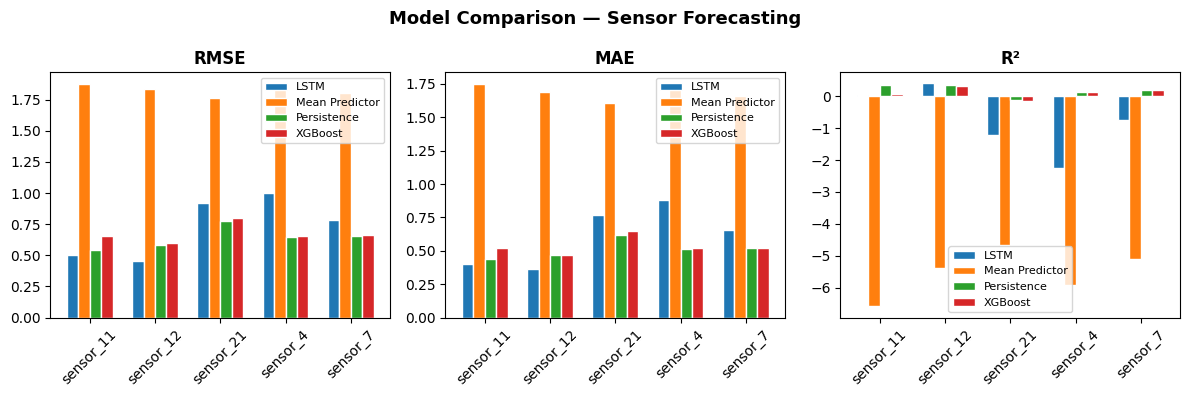

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics   = ['RMSE', 'MAE', 'R²']
colors    = ['steelblue', 'tomato', 'seagreen']

for ax, metric, color in zip(axes, metrics, colors):
    pivot = comparison_df.pivot(index='Sensor', columns='Model', values=metric)
    pivot.plot(kind='bar', ax=ax, edgecolor='white', width=0.7)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

plt.suptitle('Model Comparison — Sensor Forecasting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/04_model_comparison.png', bbox_inches='tight')
plt.show()

### Results

The persistence model proves to be a strong baseline across all sensors, ranking first on 3 out of 5 sensors and second on the remaining two.  
This reflects the smooth, slow-changing nature of CMAPSS degradation signals — consecutive cycles are highly correlated, making the current value a reliable proxy for the next.

XGBoost matches or approaches persistence on most sensors, confirming that the engineered features provide sufficient temporal context for tree-based forecasting.

LSTM, despite being the best model in notebook 03 for RUL prediction,
underperforms here on 3 out of 5 sensors.  
The sensor forecasting task exposes a different weakness: with only 100 training engines and smooth signals, the recurrent architecture does not have enough variability to learn meaningful short-term dynamics beyond what the persistence model already captures.

`sensor_21` is the most difficult to forecast across all models, with all approaches showing negative or near-zero R² — suggesting its signal contains more noise or non-linear dynamics than the other sensors.

## Forecast visualization

Predicted vs actual sensor values for a sample engine from the validation set — one plot per sensor showing all models against the ground truth.

In [29]:
sample_engine = val_df['engine_id'].unique()[0]
sample = val_df[val_df['engine_id'] == sample_engine].sort_values('cycle')

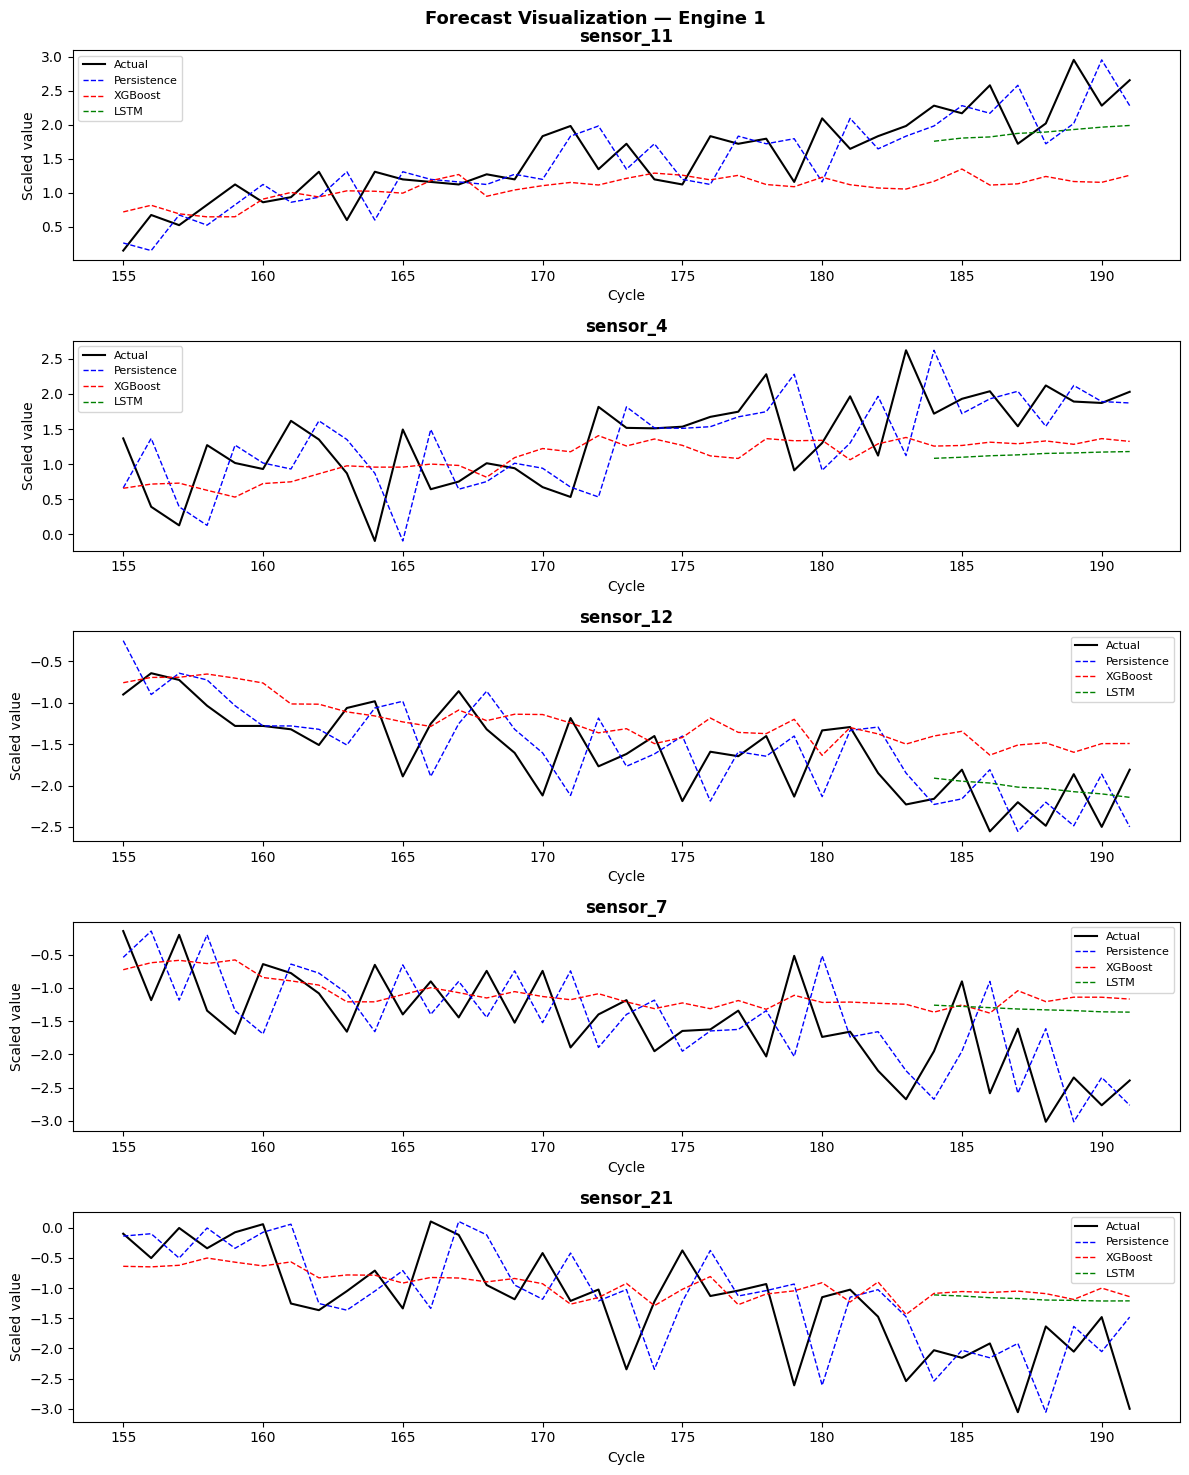

In [30]:
fig, axes = plt.subplots(len(SENSORS), 1, figsize=(12, 3 * len(SENSORS)))

for ax, s in zip(axes, SENSORS):
    cycles  = sample['cycle'].values
    actual  = sample[f'{s}_target'].values

    # Persistence
    persistence = sample[s].values

    # XGBoost
    xgb_pred = xgb_models[s].predict(sample[FEATURES])

    # LSTM
    X_seq, _ = make_sequences(sample, SENSORS, f'{s}_target', SEQ_LEN)
    lstm_pred = lstm_models[s].predict(X_seq, verbose=0).flatten()
    cycles_seq = cycles[SEQ_LEN - 1 : SEQ_LEN - 1 + len(lstm_pred)]

    ax.plot(cycles, actual, color='black', linewidth=1.5, label='Actual')
    ax.plot(cycles, persistence, color='blue', linewidth=1, linestyle='--', label='Persistence')
    ax.plot(cycles, xgb_pred, color='red', linewidth=1, linestyle='--', label='XGBoost')
    ax.plot(cycles_seq, lstm_pred, color='green', linewidth=1, linestyle='--', label='LSTM')

    ax.set_title(s, fontweight='bold')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Scaled value')
    ax.legend(fontsize=8)

plt.suptitle(f'Forecast Visualization — Engine {sample_engine}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/04_forecast_visualization.png', bbox_inches='tight')
plt.show()

### Observations

The persistence model visually tracks the actual signal well across all sensors, with a characteristic one-cycle shift — a direct consequence of predicting the current value as the next.  
- On smooth signals this delay is negligible;
- on high-variance signals it becomes the main source of error.

LSTM tends to predict a near-constant value on most sensors, converging toward the signal mean rather than following cycle-to-cycle dynamics.  
This is expected behaviour on a small dataset — with only 100 training engines and noisy signals, the model minimises loss by predicting the average trend rather than local oscillations.

`sensor_21` is the hardest to forecast across all models.  
Its large inter-cycle amplitude swings make short-term prediction inherently unreliable — no model manages to track the sharp drops and recoveries visible in the signal.

## Error analysis

Residual distribution for the best model per sensor — to understand whether errors are systematic or random.

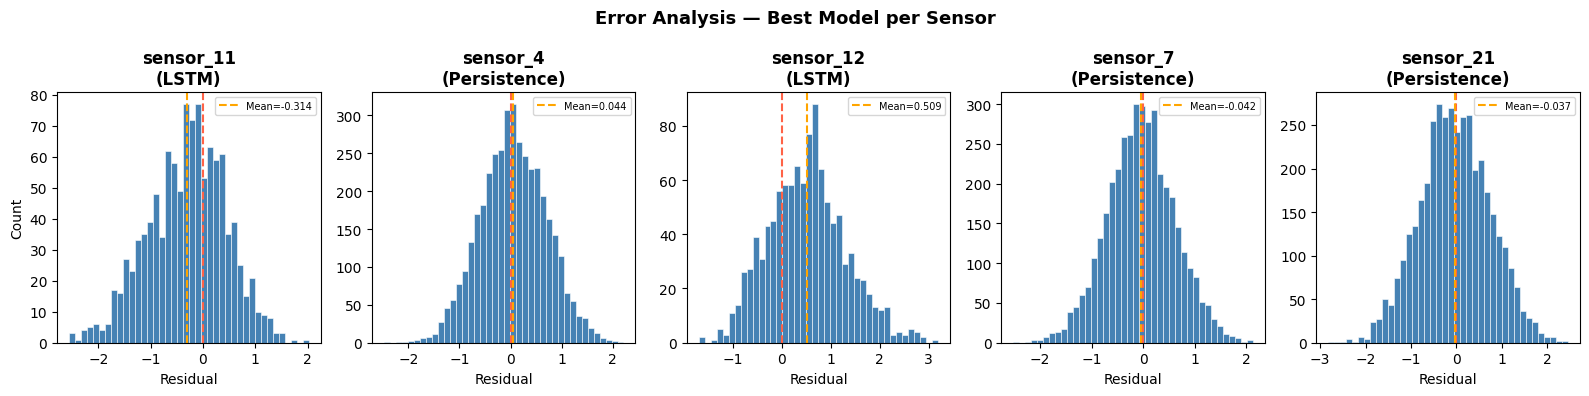

In [31]:
fig, axes = plt.subplots(1, len(SENSORS), figsize=(16, 4))

for ax, s in zip(axes, SENSORS):
    # best model per sensor based on RMSE
    best_model = min(results[s], key=lambda m: results[s][m]['RMSE'])

    if best_model == 'Persistence':
        preds = val_df[s].values
    elif best_model == 'XGBoost':
        preds = xgb_models[s].predict(val_df[FEATURES])
    else:
        X_seq, _ = make_sequences(val_df, SENSORS, f'{s}_target', SEQ_LEN)
        preds = lstm_models[s].predict(X_seq, verbose=0).flatten()

    actual    = val_df[f'{s}_target'].values[:len(preds)]
    residuals = actual - preds

    ax.hist(residuals, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='tomato', linestyle='--', linewidth=1.5)
    ax.axvline(residuals.mean(), color='orange', linestyle='--',
               linewidth=1.5, label=f'Mean={residuals.mean():.3f}')
    ax.set_title(f'{s}\n({best_model})', fontweight='bold')
    ax.set_xlabel('Residual')
    ax.legend(fontsize=7)

axes[0].set_ylabel('Count')
plt.suptitle('Error Analysis — Best Model per Sensor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/04_error_analysis.png', bbox_inches='tight')
plt.show()

### Observations

`sensor_11`, `sensor_4` and `sensor_7` (Persistence) show symmetric residual distributions centered near zero, confirming the model is essentially unbiased on these signals.

`sensor_12` (LSTM) is the only sensor where LSTM wins, but its residual distribution is noticeably off-center and left-skewed — the model systematically overestimates the next value, likely due to the downward trend in the signal that LSTM partially captures but consistently lags behind.

`sensor_21` (Persistence) shows a right-skewed distribution despite being centered near zero — reflecting the asymmetric nature of its sharp downward
spikes, which cause large negative residuals that persistence cannot anticipate.

## Save best model

The best model per sensor is saved for use in notebook 05 — anomaly detection will compare actual sensor readings against these forecasts to identify deviations.

In [36]:
MODEL_DIR = '../outputs/sensor_forecasting_model/'

In [37]:
lstm_models['sensor_12'].save(os.path.join(MODEL_DIR, 'lstm_sensor_12.keras'))
print('Saved: lstm_sensor_12.keras')

Saved: lstm_sensor_12.keras


In [38]:
comparison_df.to_csv(os.path.join(MODEL_DIR, 'sensor_forecast_results.csv'),
                     index=False)

In [39]:
joblib.dump(SENSORS, os.path.join(MODEL_DIR, 'sensors.pkl'))
print('Sensors dumped at: %s' % os.path.join(MODEL_DIR, 'sensors.pkl'))
joblib.dump(FEATURES, os.path.join(MODEL_DIR, 'features.pkl'))
print('Features dumped at: %s' % os.path.join(MODEL_DIR, 'features.pkl'))

Sensors dumped at: ../outputs/sensor_forecasting_model/sensors.pkl
Features dumped at: ../outputs/sensor_forecasting_model/features.pkl
